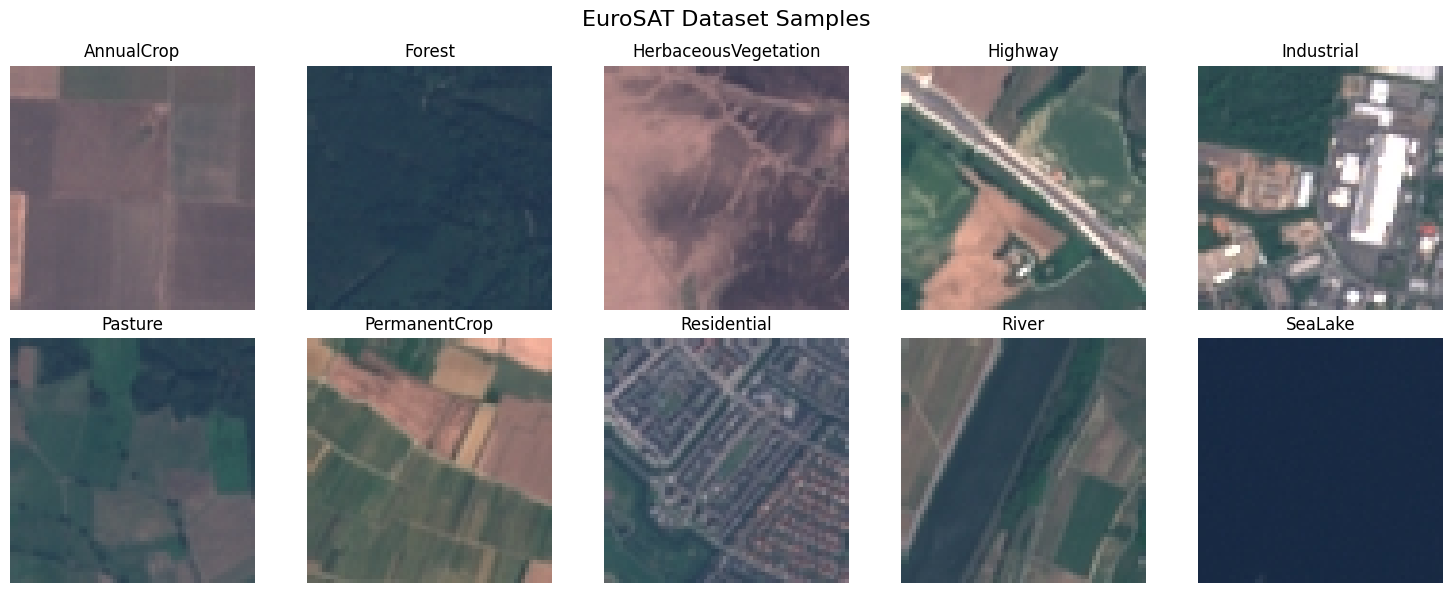

Dataset size: 27000
Number of classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [1]:
import torch
import torchvision
from torchvision import datasets, transforms
import numpy as np

import matplotlib.pyplot as plt

# Define transform to convert images to tensor
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load EuroSAT dataset
dataset = datasets.EuroSAT(root='./data', download=True, transform=transform)

# Get class names
class_names = dataset.classes

# Plot samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('EuroSAT Dataset Samples', fontsize=16)

# Get one sample from each class
samples_per_class = {}
for i in range(len(dataset)):
    image, label = dataset[i]
    class_name = class_names[label]
    if class_name not in samples_per_class:
        samples_per_class[class_name] = (image, label)
    if len(samples_per_class) == len(class_names):
        break

# Plot one sample from each class
for i, (class_name, (image, label)) in enumerate(samples_per_class.items()):
    row = i // 5
    col = i % 5
    
    # Convert tensor to numpy array for plotting
    image_np = image.permute(1, 2, 0).numpy()
    
    axes[row, col].imshow(image_np)
    axes[row, col].set_title(f'{class_name}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print(f"Dataset size: {len(dataset)}")
print(f"Number of classes: {len(class_names)}")
print(f"Classes: {class_names}")

In [5]:
image.shape

torch.Size([3, 64, 64])

In [ ]:
import pytorch_lightning as pl
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch
from collections import defaultdict
from sklearn.model_selection import train_test_split

class EuroSATDataModule(pl.LightningDataModule):
    total_samples = 27000

    @property
    def num_classes(self):
        return 10
        
    _MEAN = [0.3444, 0.3803, 0.4078]
    _STD = [0.0914, 0.0651, 0.0552]

    def __init__(self, data_dir: str = "./data", batch_size: int = 32, num_workers: int = 4):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        
        # Define transforms
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=EuroSATDataModule._MEAN, 
                               std=EuroSATDataModule._STD)
        ])
        
        self.train_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=EuroSATDataModule._MEAN,
                               std=EuroSATDataModule._STD)
        ])
    
    def prepare_data(self):
        # Download dataset
        full_dataset = datasets.EuroSAT(root=self.data_dir, download=True)
        indices = list(range(len(full_dataset)))
        labels = [full_dataset[i][1] for i in indices]  # class labels
        self.train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=labels, random_state=42)
        self.val_idx, self.test_idx = train_test_split(temp_idx, test_size=0.5, stratify=[labels[i] for i in temp_idx], random_state=42)

    def setup(self, stage: str = None):
        # Load full dataset
        traintest_dataset = datasets.EuroSAT(root=self.data_dir, transform=self.train_transform)
        valid_dataset = datasets.EuroSAT(root=self.data_dir, transform=self.transform)

        self.train_dataset = torch.utils.data.Subset(traintest_dataset, self.train_idx)
        self.val_dataset = torch.utils.data.Subset(valid_dataset, self.val_idx)
        self.test_dataset = torch.utils.data.Subset(traintest_dataset, self.test_idx)

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=True
        )
    
    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True
        )
    
    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True
        )

In [3]:
# Create data module instance to calculate normalization statistics
data_module = EuroSATDataModule(data_dir="./data", batch_size=64)
data_module.prepare_data()
data_module.setup(None)

# Load dataset without normalization to calculate stats
raw_dataset = datasets.EuroSAT(root='./data', transform=transforms.ToTensor())
dataloader = DataLoader(raw_dataset, batch_size=64, shuffle=False, num_workers=4)

# Calculate mean and std for each channel
mean = torch.zeros(3)
std = torch.zeros(3)
total_samples = 0

print("Calculating normalization statistics...")

for data, _ in dataloader:
    batch_samples = data.size(0)
    data = data.view(batch_samples, data.size(1), -1)
    mean += data.mean(2).sum(0)
    std += data.std(2).sum(0)
    total_samples += batch_samples

mean /= total_samples
std /= total_samples

print(f"Mean: {mean}")
print(f"Std: {std}")
print(f"Total samples processed: {total_samples}")

Calculating normalization statistics...
Mean: tensor([0.3444, 0.3803, 0.4078])
Std: tensor([0.0914, 0.0651, 0.0552])
Total samples processed: 27000


In [4]:
# check the normalization of train/val/test
train_loader = data_module.train_dataloader()
val_loader = data_module.val_dataloader()
test_loader = data_module.test_dataloader()
# print mean/std
def compute_mean_std(loader):
    mean = torch.zeros(3)
    std = torch.zeros(3)
    total_samples = 0

    for data, _ in loader:
        batch_samples = data.size(0)
        data = data.view(batch_samples, data.size(1), -1)
        mean += data.mean(2).sum(0)
        std += data.std(2).sum(0)
        total_samples += batch_samples

    mean /= total_samples
    std /= total_samples
    return mean, std
train_mean, train_std = compute_mean_std(train_loader)
val_mean, val_std = compute_mean_std(val_loader)
test_mean, test_std = compute_mean_std(test_loader)
print(f"Train Mean: {train_mean}, Train Std: {train_std}")
print(f"Val Mean: {val_mean}, Val Std: {val_std}")  
print(f"Test Mean: {test_mean}, Test Std: {test_std}")

/Users/karella/.conda/envs/hippy2d/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Mean: tensor([-0.0055, -0.0053, -0.0045]), Train Std: tensor([0.9994, 0.9995, 1.0000])
Val Mean: tensor([ 0.0048,  0.0041, -0.0005]), Val Std: tensor([0.9982, 0.9986, 0.9990])
Test Mean: tensor([0.0189, 0.0197, 0.0181]), Test Std: tensor([1.0031, 1.0064, 1.0065])
